In [1]:
# Import library
import wrds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
# Create a folder for saving images.
if not os.path.exists('images'):
    os.makedirs('images')

plt.rcParams['font.sans-serif'] = ['Deja Sans']
sns.set_style("whitegrid")

In [3]:
# ---------------------- Connect to WRDS ----------------------
db = wrds.Connection(wrds_username="qqhhzz")

Loading library list...
Done


In [4]:
# Obtain US stock financial data (for the most recent year)
us_data = db.raw_sql("""
SELECT gvkey, conm, datadate, ni, at, seq, sale, cogs, lt, exchg, fic
FROM comp.funda
WHERE indfmt='INDL' AND datafmt='STD' AND popsrc='D' AND consol='C'
AND datadate >= '2023-01-01' AND datadate <= '2024-12-31'
AND exchg IN (11,12,14)
LIMIT 500;
""")


In [5]:
# 2. Check the company's main statements and obtain the SIC industry code.（comp.company）
company_data = db.raw_sql("""
SELECT gvkey, sic
FROM comp.company
WHERE gvkey IN (
    SELECT DISTINCT gvkey FROM comp.funda
    WHERE indfmt='INDL' AND datafmt='STD' AND popsrc='D' AND consol='C'
    AND datadate >= '2023-01-01' AND datadate <= '2024-12-31'
    AND exchg IN (11,12,14)
)
LIMIT 1000;
""")


In [6]:
# 3. Merge the data by joining the two tables using gvkey.
df = us_data.merge(company_data, on='gvkey', how='left')

In [7]:
# output datas
print("Number of rows in merged data：", len(df))
print(df[['gvkey', 'conm', 'sic']].head())

Number of rows in merged data： 500
    gvkey                         conm   sic
0  001004                     AAR CORP  5080
1  001004                     AAR CORP  5080
2  001045  AMERICAN AIRLINES GROUP INC  4512
3  001045  AMERICAN AIRLINES GROUP INC  4512
4  001050      CECO ENVIRONMENTAL CORP  3564


In [8]:
print("Number of rows of US stock data：",len(us_data))
print(us_data.head())

Number of rows of US stock data： 500
    gvkey                         conm    datadate      ni       at      seq  \
0  001004                     AAR CORP  2023-05-31    90.2   1833.1   1099.1   
1  001004                     AAR CORP  2024-05-31    46.3   2770.0   1189.8   
2  001045  AMERICAN AIRLINES GROUP INC  2023-12-31   822.0  63058.0  -5202.0   
3  001045  AMERICAN AIRLINES GROUP INC  2024-12-31   846.0  61783.0  -3977.0   
4  001050      CECO ENVIRONMENTAL CORP  2023-12-31  12.911  600.291  232.643   

      sale     cogs       lt  exchg  fic  
0   1990.6   1591.3    734.0     11  USA  
1   2321.2   1835.4   1580.2     11  USA  
2  52788.0  38716.0  68260.0     14  USA  
3  54211.0  40501.0  65760.0     14  USA  
4  544.845  369.206    362.8     14  USA  


In [9]:
def get_industry(sic):
    if pd.isna(sic):
        return 'Other'
    sic = int(sic)
    if 7300 <= sic <= 7399 or 3570 <= sic <= 3579:
        return 'Technology'
    elif 2000 <= sic <= 2999 or 5200 <= sic <= 5999:
        return 'Consumer'
    elif 8000 <= sic <= 8099 or 2830 <= sic <= 2839:
        return 'Healthcare'
    elif 6000 <= sic <= 6999:
        return 'Financials'
    else:
        return 'Other'

df['Industry'] = df['sic'].apply(get_industry)
df = df[df['Industry'] != 'Other'].copy()

print(df.head())

     gvkey                          conm    datadate       ni        at  \
6   001062  ASA GOLD AND PRECIOUS METALS  2023-11-30    9.726   335.619   
7   001062  ASA GOLD AND PRECIOUS METALS  2024-11-30  115.296   445.398   
10  001076             PROG HOLDINGS INC  2023-12-31  138.838  1491.255   
11  001076             PROG HOLDINGS INC  2024-12-31  197.249  1513.767   
18  001119   ADAMS DIVERSIFIED EQUITY FD  2023-12-31     <NA>      <NA>   

        seq      sale     cogs       lt  exchg  fic   sic    Industry  
6   334.912     2.394    3.473    0.707     11  BMU  6799  Financials  
7   444.154      2.14     3.78    1.244     11  BMU  6799  Financials  
10  591.331  2408.264  558.936  899.924     11  USA  6141  Financials  
11  650.281  2463.496  597.545  863.486     11  USA  6141  Financials  
18     <NA>      <NA>     <NA>     <NA>     11  USA  6726  Financials  


In [10]:
# ---------------------- Calculate financial indicators ----------------------
df['ROA'] = df['ni'] / df['at']
df['Debt_Ratio'] = df['lt'] / df['at']
df['Gross_Margin'] = (df['sale'] - df['cogs']) / df['sale']

In [11]:
# ---------------------- Clean outliers ----------------------
df_clean = df.copy()
df_clean = df_clean[(df_clean['ROA'] > -0.3) & (df_clean['ROA'] < 0.3)]
df_clean = df_clean[(df_clean['Debt_Ratio'] >= 0) & (df_clean['Debt_Ratio'] < 1)]
df_clean = df_clean[(df_clean['Gross_Margin'] > -0.1) & (df_clean['Gross_Margin'] < 1)]

In [12]:
#  View the first 10 rows of data.
print("=== The first 10 rows of financial data ===")
print(df_clean[['gvkey', 'conm', 'Industry', 'ROA', 'Debt_Ratio', 'Gross_Margin']].head(10))

=== The first 10 rows of financial data ===
     gvkey                          conm    Industry       ROA  Debt_Ratio  \
10  001076             PROG HOLDINGS INC  Financials  0.093101    0.603468   
11  001076             PROG HOLDINGS INC  Financials  0.130303    0.570422   
25  001209  AIR PRODUCTS & CHEMICALS INC    Consumer  0.071876    0.510654   
26  001209  AIR PRODUCTS & CHEMICALS INC    Consumer  0.096734    0.528139   
34  001257               ALEXANDER'S INC  Financials   0.07296     0.83069   
35  001257               ALEXANDER'S INC  Financials   0.03239    0.868143   
51  001410            ABM INDUSTRIES INC  Technology  0.050935    0.635183   
52  001410            ABM INDUSTRIES INC  Technology   0.01597    0.650416   
53  001414                 PRIMERICA INC  Financials  0.038369    0.862523   
54  001414                 PRIMERICA INC  Financials  0.032315     0.84508   

    Gross_Margin  
10      0.767909  
11       0.75744  
25       0.40677  
26      0.444854  
34

In [13]:
# Group by industry and calculate the average of each indicator.
industry_metrics = df_clean.groupby('Industry')[['ROA', 'Debt_Ratio', 'Gross_Margin']].mean()
print("Average values of financial indicators by industry：")
print(industry_metrics)

Average values of financial indicators by industry：
                 ROA  Debt_Ratio  Gross_Margin
Industry                                      
Consumer    0.058121    0.577551      0.379971
Financials  0.025824    0.741271      0.456647
Healthcare  0.081567    0.356168      0.486815
Technology  0.037762    0.546414       0.46355


In [14]:
# ---------------------- Close the connection ----------------------
db.close()

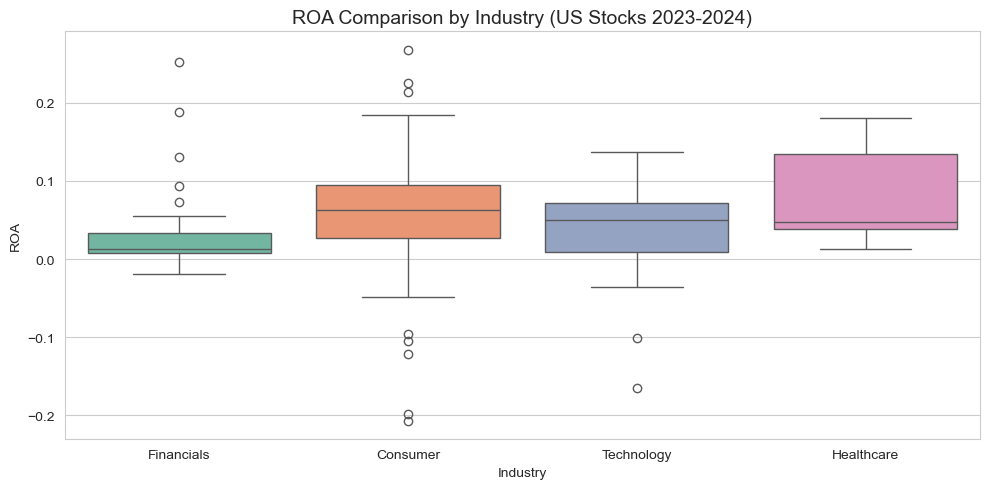

In [15]:
# Plot 1: ROA by Industry
plt.figure(figsize=(10, 5))
sns.boxplot(x='Industry', y='ROA', hue='Industry', data=df_clean, palette='Set2', legend=False)
plt.title('ROA Comparison by Industry (US Stocks 2023-2024)', fontsize=14)
plt.tight_layout()
plt.savefig('images/roa_by_industry.png', dpi=300)
plt.show()

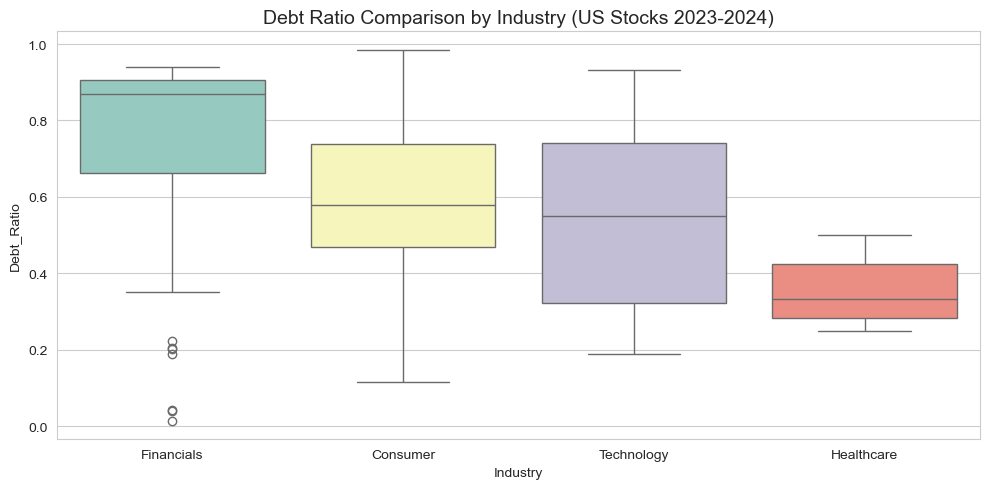

In [16]:
# ---------------------- Plot 2: Debt Ratio by Industry ----------------------
plt.figure(figsize=(10, 5))
# Add the hue parameter and set legend=False
sns.boxplot(x='Industry', y='Debt_Ratio', hue='Industry', data=df_clean, palette='Set3', legend=False)
plt.title('Debt Ratio Comparison by Industry (US Stocks 2023-2024)', fontsize=14)
plt.tight_layout()
plt.savefig('images/debt_ratio_by_industry.png', dpi=300)
plt.show()

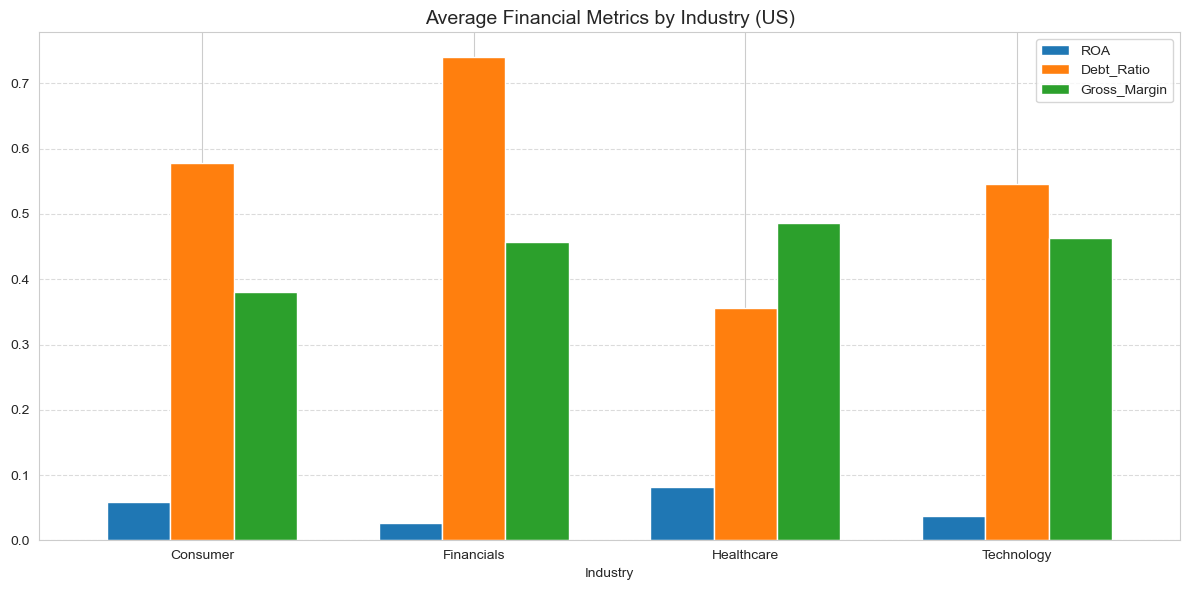

In [17]:
# ---------------------- Plot 3: Average Metrics Bar Chart ----------------------
industry_mean = df_clean.groupby('Industry')[['ROA', 'Debt_Ratio', 'Gross_Margin']].mean()

plt.figure(figsize=(12, 6))
industry_mean.plot(kind='bar', ax=plt.gca(), width=0.7)
plt.title('Average Financial Metrics by Industry (US)', fontsize=14)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('images/industry_avg_metrics.png', dpi=300)
plt.show()